# ☀️ Análisis de Potencial Solar (PVOUT) por Distrito
## Región Arequipa — Proyección de Paneles Solares, Consumo y Presupuesto

Este notebook analiza el potencial fotovoltaico (PVOUT) de 8 distritos de la región Arequipa (Perú),
estimando cuántos paneles solares se necesitarían para alimentar computadoras en horario laboral,
el espacio requerido, el presupuesto estimado y otros indicadores clave.

**Fuente de datos:** PVOUT (Photovoltaic Power Output) expresado en kWh/kWp/año — indica cuánta


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#F4A300','#E05C1A','#2C7BB6','#1A9641','#D7191C','#ABDDA4','#FDAE61','#4575B4']

df = pd.read_csv('../data/cleaned/unique_districts_pvout.csv')
df['PVOUT'] = pd.to_numeric(df['PVOUT'], errors='coerce')
df = df.dropna(subset=['PVOUT'])
print(f"Datos cargados correctamente ✓: {len(df)} distritos")
df.head()


Datos cargados correctamente ✓: 109 distritos


,DISTRITO,LATITUD,LONGITUD,PVOUT
0,ACARI,-15.432500,-74.617222,1729.1
1,ACHOMA,-15.661111,-71.701667,2016.8
2,ALCA,-15.134167,-72.764722,1777.6
3,ALTO SELVA ALEGRE,-16.370556,-71.527222,2026.3
4,ANDAGUA,-15.497500,-72.355000,2040.2


## 2. Especificaciones Técnicas Adoptadas

| Parámetro | Valor | Justificación |
|---|---|---|
| Potencia por panel | **550 Wp** | Módulos monocristalinos Tier-1 (JA Solar, Longi, etc.) |
| Eficiencia del panel | **21.3 %** | Tecnología PERC/TOPCon 2024 |
| Área por panel | **2.21 m²** | Formato 144 half-cells (2.278 × 0.969 m) |
| Pérdidas del sistema (PR) | **80 %** | Cableado + inversor + temperatura + sombras |
| Inversor | String inverter 98 % eficiencia | Growatt / SMA |
| Consumo PC de oficina | **150 W** promedio | CPU + monitor 24" |
| Horas de uso escolar/día | **6 h** (08:00–14:00) | Horario escolar L–V |
| Días escolares/año | **200 días** | Año escolar Perú RM 556-2014 |
| Vida útil sistema | **25 años** | Garantía estándar paneles |
| Costo panel (instalado) | **USD 180/panel** | Precio mercado Perú 2024 |
| Balance of System | **30 %** sobre paneles | Inversor, estructura, cableado, mano de obra |
| O&M anual | **1 %** del CAPEX | Limpieza y revisiones periódicas |
| **Máx. PCs por aula (MINEDU)** | **35 PCs** | RM 556-2014: primaria/secundaria urbana polidocente |
| Escenarios evaluados | **15, 20, 30, 35 PCs** | Rural unidocente → urbana polidocente máx. |

In [3]:
PANEL_WP       = 550
PANEL_AREA_M2  = 2.21
PR             = 0.80
PC_POWER_W     = 150
HOURS_WORK_DAY = 6  # horas de clase por día (horario escolar)
DAYS_WORK_YEAR = 200  # días escolares/año (RM 556-2014 MINEDU)
PANEL_COST_USD = 180
BOS_FACTOR     = 0.30
OM_FACTOR      = 0.01
SYSTEM_LIFE_YR = 25
USD_TO_PEN     = 3.75
PC_SCENARIOS   = [15, 20, 30, 35]


## 3. Motor de Cálculo

**Energía demandada por PC al año:**

$$E_{PC} = 150\,W \times 8\,h \times 250\,dias = 300\,kWh/año$$

**Producción real por panel:**

$$E_{panel} = \frac{P_{panel}[kWp] \times PVOUT \times PR}{1} $$

**Paneles necesarios para N PCs:**



In [4]:
E_PC_KWH_YEAR = (PC_POWER_W / 1000) * HOURS_WORK_DAY * DAYS_WORK_YEAR
print(f"Energía anual por PC: {E_PC_KWH_YEAR:.0f} kWh/año")

df["E_PANEL_KWH_YEAR"] = ((PANEL_WP / 1000) * df["PVOUT"] * PR).round(2)
df["PCS_POR_PANEL"]    = (df["E_PANEL_KWH_YEAR"] / E_PC_KWH_YEAR).round(2)

print("\nProducción por panel y PCs equivalentes por distrito:")
df[["DISTRITO","PVOUT","E_PANEL_KWH_YEAR","PCS_POR_PANEL"]]

Energía anual por PC: 180 kWh/año

Producción por panel y PCs equivalentes por distrito:


,DISTRITO,PVOUT,E_PANEL_KWH_YEAR,PCS_POR_PANEL
0,ACARI,1729.1,760.80,4.23
1,ACHOMA,2016.8,887.39,4.93
2,ALCA,1777.6,782.14,4.35
3,ALTO SELVA ALEGRE,2026.3,891.57,4.95
4,ANDAGUA,2040.2,897.69,4.99
...,...,...,...,...
104,YANAQUIHUA,2016.4,887.22,4.93
105,YANQUE,2010.3,884.53,4.91
106,YARABAMBA,2035.6,895.66,4.98
107,YAUCA,1840.2,809.69,4.50


In [5]:
def calc_scenario(row, n_pcs):
    e_total   = n_pcs * E_PC_KWH_YEAR
    n_panels  = int(np.ceil(e_total / row["E_PANEL_KWH_YEAR"]))
    area_m2   = n_panels * PANEL_AREA_M2
    kWp       = n_panels * PANEL_WP / 1000
    capex_usd = n_panels * PANEL_COST_USD * (1 + BOS_FACTOR)
    om_yr     = capex_usd * OM_FACTOR
    total_25  = capex_usd + om_yr * SYSTEM_LIFE_YR
    e_gen     = row["E_PANEL_KWH_YEAR"] * n_panels
    lcoe      = total_25 / (e_gen * SYSTEM_LIFE_YR)
    payback   = capex_usd / max(e_total * 0.06 - om_yr, 0.01)
    co2_yr    = e_gen * 0.5  # kg CO2 evitado (factor 0.5 kg/kWh red Peru)
    return {
        "N_PCS":          n_pcs,
        "N_PANELES":      n_panels,
        "AREA_M2":        round(area_m2, 1),
        "KWP_TOTAL":      round(kWp, 2),
        "E_GEN_KWH_YR":   round(e_gen, 0),
        "E_DEM_KWH_YR":   round(e_total, 0),
        "EXCEDENTE_PCT":  round((e_gen / e_total - 1) * 100, 1),
        "CAPEX_USD":      round(capex_usd, 0),
        "CAPEX_PEN":      round(capex_usd * USD_TO_PEN, 0),
        "OM_USD_YR":      round(om_yr, 0),
        "TOTAL_25YR_USD": round(total_25, 0),
        "LCOE_USD_KWH":   round(lcoe, 4),
        "PAYBACK_ANIOS":  round(payback, 1),
        "CO2_EVIT_KG_YR": round(co2_yr, 0),
    }

records = []
for _, row in df.iterrows():
    for n_pcs in PC_SCENARIOS:
        rec = {"DISTRITO": row["DISTRITO"], "PVOUT": row["PVOUT"]}
        rec.update(calc_scenario(row, n_pcs))
        records.append(rec)

df_full = pd.DataFrame(records)
print(f"Tabla generada: {len(df_full)} filas")
df_full.head(8)

Tabla generada: 436 filas


,DISTRITO,PVOUT,N_PCS,N_PANELES,AREA_M2,KWP_TOTAL,E_GEN_KWH_YR,E_DEM_KWH_YR,EXCEDENTE_PCT,CAPEX_USD,CAPEX_PEN,OM_USD_YR,TOTAL_25YR_USD,LCOE_USD_KWH,PAYBACK_ANIOS,CO2_EVIT_KG_YR
0,ACARI,1729.1,15,4,8.8,2.20,3043.0,2700.0,12.7,936.0,3510.0,9.0,1170.0,0.0154,6.1,1522.0
1,ACARI,1729.1,20,5,11.1,2.75,3804.0,3600.0,5.7,1170.0,4388.0,12.0,1462.0,0.0154,5.7,1902.0
2,ACARI,1729.1,30,8,17.7,4.40,6086.0,5400.0,12.7,1872.0,7020.0,19.0,2340.0,0.0154,6.1,3043.0
3,ACARI,1729.1,35,9,19.9,4.95,6847.0,6300.0,8.7,2106.0,7898.0,21.0,2632.0,0.0154,5.9,3424.0
4,ACHOMA,2016.8,15,4,8.8,2.20,3550.0,2700.0,31.5,936.0,3510.0,9.0,1170.0,0.0132,6.1,1775.0
5,ACHOMA,2016.8,20,5,11.1,2.75,4437.0,3600.0,23.2,1170.0,4388.0,12.0,1462.0,0.0132,5.7,2218.0
6,ACHOMA,2016.8,30,7,15.5,3.85,6212.0,5400.0,15.0,1638.0,6142.0,16.0,2048.0,0.0132,5.3,3106.0
7,ACHOMA,2016.8,35,8,17.7,4.40,7099.0,6300.0,12.7,1872.0,7020.0,19.0,2340.0,0.0132,5.2,3550.0


In [6]:
OUTPUT_CSV = "solar_pvout_proyeccion.csv"
df_full.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"✅ Archivo exportado: {OUTPUT_CSV}")
print(f"   Columnas : {list(df_full.columns)}")
print(f"   Filas    : {len(df_full)}")
df_full

✅ Archivo exportado: solar_pvout_proyeccion.csv
   Columnas : ['DISTRITO', 'PVOUT', 'N_PCS', 'N_PANELES', 'AREA_M2', 'KWP_TOTAL', 'E_GEN_KWH_YR', 'E_DEM_KWH_YR', 'EXCEDENTE_PCT', 'CAPEX_USD', 'CAPEX_PEN', 'OM_USD_YR', 'TOTAL_25YR_USD', 'LCOE_USD_KWH', 'PAYBACK_ANIOS', 'CO2_EVIT_KG_YR']
   Filas    : 436


,DISTRITO,PVOUT,N_PCS,N_PANELES,AREA_M2,KWP_TOTAL,E_GEN_KWH_YR,E_DEM_KWH_YR,EXCEDENTE_PCT,CAPEX_USD,CAPEX_PEN,OM_USD_YR,TOTAL_25YR_USD,LCOE_USD_KWH,PAYBACK_ANIOS,CO2_EVIT_KG_YR
0,ACARI,1729.1,15,4,8.8,2.20,3043.0,2700.0,12.7,936.0,3510.0,9.0,1170.0,0.0154,6.1,1522.0
1,ACARI,1729.1,20,5,11.1,2.75,3804.0,3600.0,5.7,1170.0,4388.0,12.0,1462.0,0.0154,5.7,1902.0
2,ACARI,1729.1,30,8,17.7,4.40,6086.0,5400.0,12.7,1872.0,7020.0,19.0,2340.0,0.0154,6.1,3043.0
3,ACARI,1729.1,35,9,19.9,4.95,6847.0,6300.0,8.7,2106.0,7898.0,21.0,2632.0,0.0154,5.9,3424.0
4,ACHOMA,2016.8,15,4,8.8,2.20,3550.0,2700.0,31.5,936.0,3510.0,9.0,1170.0,0.0132,6.1,1775.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,YAUCA,1840.2,35,8,17.7,4.40,6478.0,6300.0,2.8,1872.0,7020.0,19.0,2340.0,0.0144,5.2,3239.0
432,YURA,2072.9,15,3,6.6,1.65,2736.0,2700.0,1.3,702.0,2632.0,7.0,878.0,0.0128,4.5,1368.0
433,YURA,2072.9,20,4,8.8,2.20,3648.0,3600.0,1.3,936.0,3510.0,9.0,1170.0,0.0128,4.5,1824.0
434,YURA,2072.9,30,6,13.3,3.30,5472.0,5400.0,1.3,1404.0,5265.0,14.0,1755.0,0.0128,4.5,2736.0


## 5. Visualizaciones



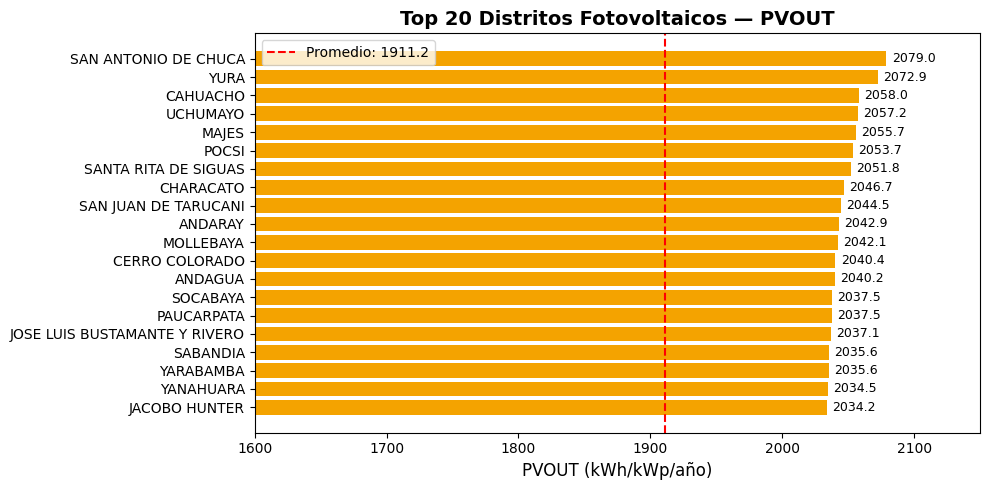

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df_s = df.sort_values("PVOUT").tail(20)
bars = ax.barh(df_s["DISTRITO"], df_s["PVOUT"], color="#F4A300")
ax.set_xlabel("PVOUT (kWh/kWp/año)", fontsize=12)
ax.set_title("Top 20 Distritos Fotovoltaicos — PVOUT", fontsize=14, fontweight="bold")
for bar, val in zip(bars, df_s["PVOUT"]):
    ax.text(val + 4, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center", fontsize=9)
ax.set_xlim(1600, 2150)
ax.axvline(df["PVOUT"].mean(), color="red", linestyle="--", lw=1.5,
           label=f"Promedio: {df['PVOUT'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_pvout_ranking.png", dpi=150)


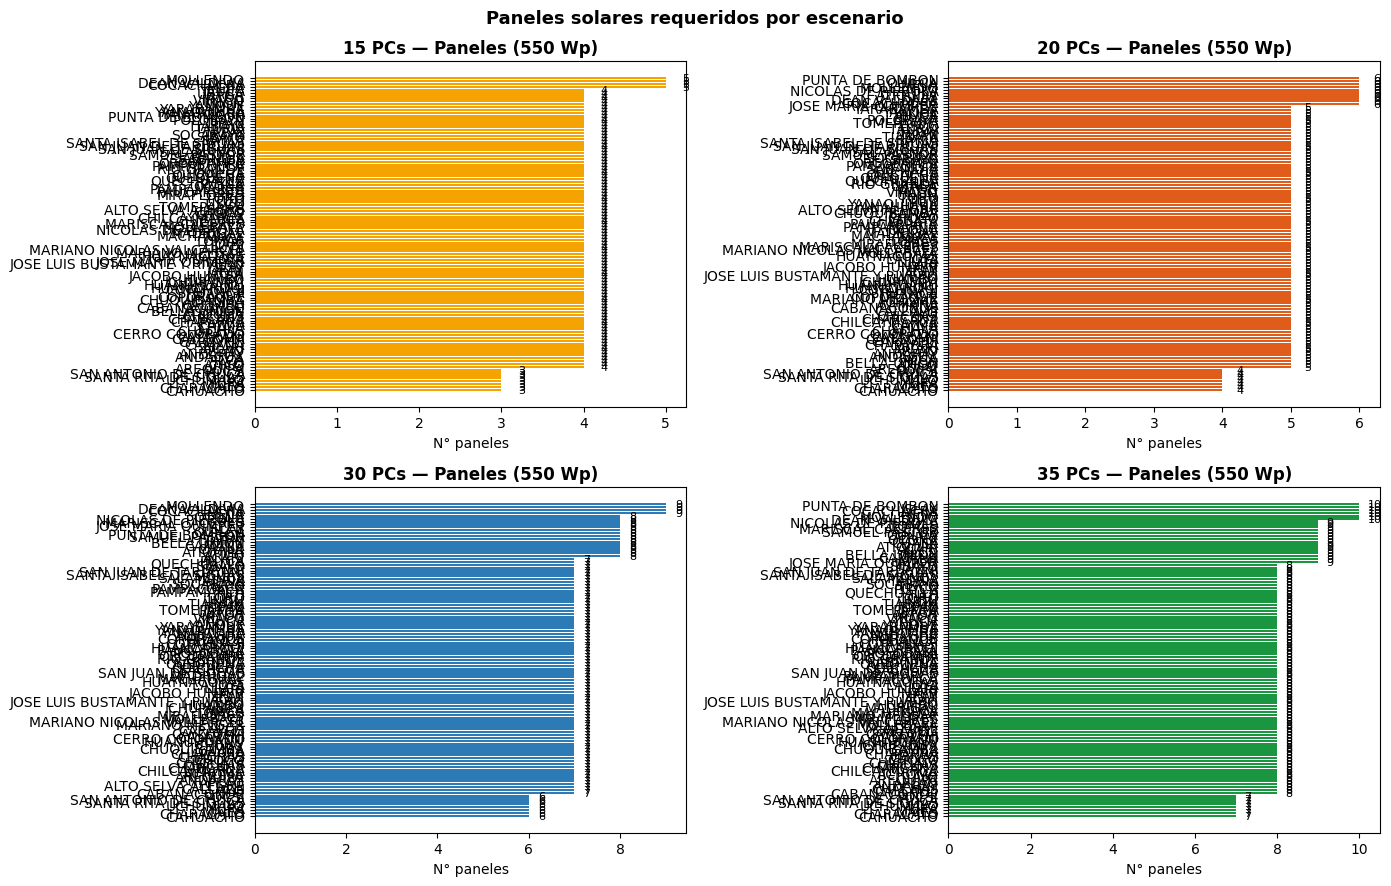

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, n_pcs in enumerate(PC_SCENARIOS):
    sub = df_full[df_full["N_PCS"] == n_pcs].sort_values("N_PANELES")
    axes[i].barh(sub["DISTRITO"], sub["N_PANELES"], color=PALETTE[i])
    axes[i].set_title(f"{n_pcs} PCs — Paneles (550 Wp)", fontweight="bold")
    axes[i].set_xlabel("N° paneles")
    for bar, val in zip(axes[i].patches, sub["N_PANELES"]):
        axes[i].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                     str(val), va="center", fontsize=8)
plt.suptitle("Paneles solares requeridos por escenario", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_paneles_escenarios.png", dpi=150)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
top20_dist = df.sort_values("PVOUT", ascending=False).head(20)["DISTRITO"]
pivot = df_full[df_full["DISTRITO"].isin(top20_dist)].pivot(index="DISTRITO", columns="N_PCS", values="CAPEX_USD")
pivot.plot(kind="bar", ax=ax, colormap="viridis", width=0.75)
ax.set_title("CAPEX estimado (USD) — Top 20 Distritos mayor PVOUT", fontsize=13, fontweight="bold")
ax.set_xlabel("Distrito")
ax.set_ylabel("CAPEX (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="N° de PCs", labels=[f"{n} PCs" for n in PC_SCENARIOS])
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("fig3_capex.png", dpi=150)


In [ ]:
s35 = df_full[df_full["N_PCS"] == 35].sort_values("LCOE_USD_KWH").head(15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars1 = ax1.bar(s35["DISTRITO"], s35["LCOE_USD_KWH"], color=PALETTE)
ax1.axhline(0.06, color="green", linestyle="--", lw=1.5, label="Tarifa red ~0.06 USD/kWh")
ax1.set_title("LCOE (USD/kWh) — 25 años, 35 PCs", fontweight="bold")
ax1.set_ylabel("LCOE (USD/kWh)")
for bar, val in zip(bars1, s35["LCOE_USD_KWH"]):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.001, f"{val:.4f}",
             ha="center", fontsize=8)
ax1.legend()
plt.setp(ax1.get_xticklabels(), rotation=35, ha="right")

bars2 = ax2.bar(s35["DISTRITO"], s35["PAYBACK_ANIOS"], color=PALETTE)
ax2.set_title("Payback (años) — 35 PCs", fontweight="bold")
ax2.set_ylabel("Años")
for bar, val in zip(bars2, s35["PAYBACK_ANIOS"]):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.1, f"{val:.1f}",
             ha="center", fontsize=9)
plt.setp(ax2.get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig("fig4_lcoe_payback.png", dpi=150)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
s35s = df_full[df_full["N_PCS"] == 35].sort_values("CO2_EVIT_KG_YR", ascending=False).head(20)
bars = ax.bar(s35s["DISTRITO"], s35s["CO2_EVIT_KG_YR"] / 1000, color="#1A9641")
ax.set_title("CO₂ evitado anualmente (toneladas) — 35 PCs", fontsize=12, fontweight="bold")
ax.set_ylabel("Toneladas CO₂/año")
for bar, val in zip(bars, s35s["CO2_EVIT_KG_YR"] / 1000):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.2f} t",
            ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("fig5_co2.png", dpi=150)


In [9]:
import folium

m = folium.Map(location=[-15.9, -72.3], zoom_start=7, tiles="CartoDB positron")

for _, row in df.iterrows():
    color = "#F4A300" if row["PVOUT"] >= 2000 else "#E05C1A" if row["PVOUT"] >= 1850 else "#2C7BB6"
    pcs_1panel = df.loc[df["DISTRITO"]==row["DISTRITO"], "PCS_POR_PANEL"].values[0]
    popup_html = (
        f"<b>{row['DISTRITO']}</b><br>"
        f"PVOUT: {row['PVOUT']} kWh/kWp/año<br>"
        f"PCs por panel: {pcs_1panel:.2f}<br>"
        f"Lat: {row['LATITUD']:.4f}, Lon: {row['LONGITUD']:.4f}"
    )
    folium.CircleMarker(
        location=[row["LATITUD"], row["LONGITUD"]],
        radius=14, color=color, fill=True, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{row['DISTRITO']}: {row['PVOUT']}"
    ).add_to(m)

m.save("mapa_pvout.html")
print("Mapa guardado: mapa_pvout.html  (ábrelo en un navegador)")
m

Mapa guardado: mapa_pvout.html  (ábrelo en un navegador)


In [ ]:
best  = df.loc[df["PVOUT"].idxmax()]
worst = df.loc[df["PVOUT"].idxmin()]
s35   = df_full[df_full["N_PCS"] == 35]

print("=" * 65)
print("        RESUMEN EJECUTIVO — ANÁLISIS SOLAR PVOUT")
print("=" * 65)
print(f"\n🏆 Mayor potencial : {best['DISTRITO']:22s} {best['PVOUT']} kWh/kWp/año")
print(f"📉 Menor potencial : {worst['DISTRITO']:22s} {worst['PVOUT']} kWh/kWp/año")
print(f"📊 PVOUT promedio  : {df['PVOUT'].mean():.1f} kWh/kWp/año  (σ={df['PVOUT'].std():.1f})")
print(f"🏫 Total distritos : {len(df)} distritos únicos de Arequipa")

print("\n── Escenario 35 PCs (Máximo MINEDU — RM 556-2014) ────────────────")
print(f"  Paneles (rango)  : {s35['N_PANELES'].min()} – {s35['N_PANELES'].max()} paneles de 550 Wp")
print(f"  Área (rango)     : {s35['AREA_M2'].min()} – {s35['AREA_M2'].max()} m²")
print(f"  CAPEX USD (rango): ${s35['CAPEX_USD'].min():,.0f} – ${s35['CAPEX_USD'].max():,.0f}")
print(f"  CAPEX PEN (rango): S/. {s35['CAPEX_PEN'].min():,.0f} – S/. {s35['CAPEX_PEN'].max():,.0f}")
print(f"  Payback (rango)  : {s35['PAYBACK_ANIOS'].min():.1f} – {s35['PAYBACK_ANIOS'].max():.1f} años")
print(f"  LCOE promedio    : {s35['LCOE_USD_KWH'].mean():.4f} USD/kWh  (red: 0.0600)")
print(f"  CO2 evitado/año  : {s35['CO2_EVIT_KG_YR'].mean()/1000:.2f} t CO₂ promedio por distrito")

print("\n── Top 10 distritos más rentables (35 PCs) ──────────────────────")
rank = s35.sort_values("LCOE_USD_KWH")[["DISTRITO","PVOUT","LCOE_USD_KWH","PAYBACK_ANIOS","N_PANELES","CAPEX_USD"]].head(10)
rank.index = range(1, len(rank)+1)
print(rank.to_string())


## 7. Interpretación y Notas Metodológicas

### Columnas del CSV exportado

| Columna | Descripción |
|---|---|
| `N_PCS` | Número de computadoras a alimentar |
| `N_PANELES` | Paneles de 550 Wp requeridos |
| `AREA_M2` | Superficie de instalación (solo paneles) |
| `KWP_TOTAL` | Potencia pico total instalada |
| `E_GEN_KWH_YR` | Energía anual generada por el sistema |
| `E_DEM_KWH_YR` | Energía anual demandada por las PCs |
| `EXCEDENTE_PCT` | % de energía sobrante (candidata a inyectar a la red) |
| `CAPEX_USD` | Inversión inicial en USD |
| `CAPEX_PEN` | Inversión inicial en soles |
| `OM_USD_YR` | Operación y mantenimiento anual |
| `TOTAL_25YR_USD` | Costo total en 25 años (CAPEX + O&M) |
| `LCOE_USD_KWH` | Costo nivelado de energía en USD/kWh |
| `PAYBACK_ANIOS` | Años para recuperar la inversión |
| `CO2_EVIT_KG_YR` | Kilogramos de CO₂ evitados por año |

### Supuestos y limitaciones
1. PVOUT es anual promedio; la producción varía mensualmente (pico en verano austral Nov–Mar).
2. Sistema **sin baterías** (grid-tied o consumo directo); el excedente podría acogerse a *net metering*.
3. Precios referenciales 2024; validar cotizaciones locales antes de tomar decisiones.
4. Se asume sombreado mínimo; recomendable hacer estudio de sombras en campo.
5. No incluye costos de permisos municipales, estudio eléctrico ni ingeniería de detalle (~5–10 % adicional).
